# PINN + Transformer scaffold — real-response inverse (ADITYA-U)

**Status: runnable scaffold, NOT physically validated.** Handoff starting point.

What this is: a 1D patch-transformer trained with a physics-informed loss to invert the
**real** `6100 x 599` response matrix `data/response_matrix.csv` — i.e. map a measured HXR
spectrum `y` to a true-energy vector `x`.

### Read before using

- **`H` is a detector response `H_d`, not the full operator `H_tot`.** (See
  `docs/open_physics_questions.md` Q1: low-energy photopeak ridge + high-energy
  photofraction collapse.) So the physics residual here constrains `x_pred` to the
  **photon spectrum entering the detector**, *not* the runaway-electron distribution `f`.
  Reaching `f` needs an electron-to-HXR operator `H_e` and `H_tot = H_d @ H_e`.
- Trained on **synthetic** data only (random bulk + Gaussian peaks + tail, forward-projected
  through `H` + Poisson noise). The synthetic family is a placeholder, not a physically
  justified RE model.
- Everything is **sum-normalized**; absolute counts/units are unresolved (Q2).
- CPU config, small model (~70k params). Runs in a few minutes; the one-time CSV load
  dominates.

### Prereqs

- `pip install -r requirements.txt` (needs `torch`).
- `data/response_matrix.csv` present locally (git-ignored — see `docs/data_setup.md`).
- Run this notebook with the **repo root** as the working directory.

## 1. Config

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Resolve repo root whether launched from repo/ or repo/v3_ml/
CWD = Path.cwd()
REPO = CWD if (CWD / "src").is_dir() else CWD.parent
assert (REPO / "src" / "response_matrix.py").exists(), f"run from the repo root; got {CWD}"
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CFG = dict(
    n_train=600,
    n_val=150,
    total_counts=1.0e4,
    patch=30,          # conv-stem stride: 6100 -> ~203 tokens
    d_model=64,
    n_heads=4,
    n_layers=2,
    dim_ff=128,
    dropout=0.1,
    epochs=25,
    batch_size=32,
    lr=3e-4,
    lambda_res=1.0,    # weight on the physics residual  || norm(x_pred @ H^T) - y ||^2
    lambda_tv=1e-3,    # weight on total-variation smoothness of x_pred
)

torch.manual_seed(SEED)
np.random.seed(SEED)
print("device:", DEVICE, "| torch", torch.__version__)

device: cpu | torch 2.13.0+cpu


## 2. Load the real response matrix

In [2]:
from src.response_matrix import load_response_matrix

rm = load_response_matrix(REPO / "data" / "response_matrix.csv")
H_np = rm.h.astype(np.float32)
n_meas, n_true = H_np.shape
H = torch.from_numpy(H_np).to(DEVICE)

print(f"H {H_np.shape}  E_meas {rm.e_meas_keV[0]:.1f}..{rm.e_meas_keV[-1]:.1f} keV  "
      f"E_true {rm.e_true_keV[0]:.1f}..{rm.e_true_keV[-1]:.1f} keV")
print(f"column sums: min {H_np.sum(0).min():.3f}  max {H_np.sum(0).max():.3f}")

H (6100, 599)  E_meas 0.5..6099.5 keV  E_true 20.0..6000.0 keV
column sums: min 0.999  max 1.000


## 3. Synthetic training data

`random_true_distribution` draws an exponential bulk + 1-3 Gaussian peaks + an optional
power-law tail, normalized to unit sum. Each `x_true` is forward-projected through the real
`H` and given one Poisson realization (`src.synthetic.simulate_counts`). Inputs `y` are
sum-normalized.

**Replace this generator** with a physically motivated RE-distribution family once the
physics questions are settled.

In [3]:
from src.synthetic import simulate_counts


def random_true_distribution(e_true_keV: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    e = np.asarray(e_true_keV, dtype=float)
    x = np.exp(-e / rng.uniform(150.0, 900.0))
    for _ in range(rng.integers(1, 4)):
        loc = rng.uniform(e.min(), e.max())
        width = rng.uniform(80.0, 500.0)
        amp = rng.uniform(0.2, 1.5)
        x += amp * np.exp(-((e - loc) ** 2) / (2.0 * width**2))
    if rng.random() < 0.5:
        p = rng.uniform(1.5, 3.5)
        x += 0.3 * (e.min() + 50.0) ** p / (e + 50.0) ** p
    x = np.clip(x, 0.0, None)
    return (x / x.sum()).astype(np.float32)


def build_dataset(n: int, seed: int):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, n_true), dtype=np.float32)
    Y = np.zeros((n, n_meas), dtype=np.float32)
    for i in range(n):
        x_true = random_true_distribution(rm.e_true_keV, rng)
        _, y_noisy = simulate_counts(H_np, x_true, CFG["total_counts"], seed=int(rng.integers(1 << 31)))
        X[i] = x_true
        s = y_noisy.sum()
        Y[i] = y_noisy / s if s > 0 else y_noisy
    return torch.from_numpy(Y), torch.from_numpy(X)


Y_train, X_train = build_dataset(CFG["n_train"], SEED + 1)
Y_val, X_val = build_dataset(CFG["n_val"], SEED + 2)
train_dl = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(Y_train, X_train), batch_size=CFG["batch_size"], shuffle=True
)
print(f"train {tuple(Y_train.shape)} -> {tuple(X_train.shape)} ; val {tuple(Y_val.shape)}")

train (600, 6100) -> (600, 599) ; val (150, 6100)


## 4. Model — `PatchTransformer1D`

6100 measured channels is too long for O(n^2) attention over raw bins, so a strided Conv1d
stem tokenizes into ~200 patches. A `TransformerEncoder` gives global mixing; the token
sequence is then linearly interpolated to the 599 true-energy bins and passed through a
pointwise head with `Softplus` (enforces `x >= 0`). Output is renormalized to unit sum.

In [4]:
class PositionalEncoding1D(nn.Module):
    def __init__(self, d_model: int, max_len: int = 4096):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


class PatchTransformer1D(nn.Module):
    def __init__(self, n_true: int, cfg: dict):
        super().__init__()
        self.n_true = n_true
        self.stem = nn.Conv1d(1, cfg["d_model"], kernel_size=cfg["patch"], stride=cfg["patch"])
        self.pos = PositionalEncoding1D(cfg["d_model"])
        layer = nn.TransformerEncoderLayer(
            d_model=cfg["d_model"], nhead=cfg["n_heads"], dim_feedforward=cfg["dim_ff"],
            dropout=cfg["dropout"], batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=cfg["n_layers"])
        self.head = nn.Sequential(
            nn.Linear(cfg["d_model"], 32), nn.ReLU(), nn.Linear(32, 1), nn.Softplus()
        )

    def forward(self, y):
        h = self.stem(y.unsqueeze(1))              # (B, d_model, n_tokens)
        h = self.pos(h.permute(0, 2, 1))           # (B, n_tokens, d_model)
        h = self.encoder(h)
        h = F.interpolate(h.permute(0, 2, 1), size=self.n_true, mode="linear", align_corners=False)
        x = self.head(h.permute(0, 2, 1)).squeeze(-1)   # (B, n_true)
        return x / x.sum(dim=1, keepdim=True).clamp_min(1e-12)


model = PatchTransformer1D(n_true, CFG).to(DEVICE)
print(f"params: {sum(p.numel() for p in model.parameters()):,}")

params: 71,041


## 5. Physics-informed loss

`loss = MSE(x_pred, x_true) + lambda_res * MSE(norm(x_pred @ H^T), y) + lambda_tv * TV(x_pred)`

The middle term is the physics constraint `y ~= H x`. **Note the caveat:** with `H = H_d`
it pins `x_pred` to the detector-input photon spectrum, not the RE distribution. Values are
small because targets are 599-vectors summing to 1 (per-bin ~1.7e-3, so MSE ~1e-6) — track
the *trend* and the shape relative-L2, not the absolute magnitude.

In [5]:
def pinn_loss(x_pred, x_true, y_meas):
    sup = F.mse_loss(x_pred, x_true)
    y_sim = x_pred @ H.T
    y_sim = y_sim / y_sim.sum(dim=1, keepdim=True).clamp_min(1e-12)
    res = F.mse_loss(y_sim, y_meas)
    tv = (x_pred[:, 1:] - x_pred[:, :-1]).abs().mean()
    total = sup + CFG["lambda_res"] * res + CFG["lambda_tv"] * tv
    return total, {"sup": sup.item(), "res": res.item(), "tv": tv.item()}


def rel_l2(a, b):
    return (torch.linalg.norm(a - b, dim=1) / torch.linalg.norm(b, dim=1).clamp_min(1e-12)).mean().item()

## 6. Train

In [6]:
opt = torch.optim.Adam(model.parameters(), lr=CFG["lr"])
hist = {"train": [], "val": [], "val_res": [], "val_l2": []}

for epoch in range(1, CFG["epochs"] + 1):
    model.train()
    running = 0.0
    for yb, xb in train_dl:
        yb, xb = yb.to(DEVICE), xb.to(DEVICE)
        opt.zero_grad()
        loss, _ = pinn_loss(model(yb), xb, yb)
        loss.backward()
        opt.step()
        running += loss.item() * len(yb)
    tl = running / len(train_dl.dataset)

    model.eval()
    with torch.no_grad():
        xp = model(Y_val.to(DEVICE))
        vloss, parts = pinn_loss(xp, X_val.to(DEVICE), Y_val.to(DEVICE))
        vl2 = rel_l2(xp, X_val.to(DEVICE))

    hist["train"].append(tl)
    hist["val"].append(vloss.item())
    hist["val_res"].append(parts["res"])
    hist["val_l2"].append(vl2)
    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch {epoch:3d} | train {tl:.3e} | val {vloss.item():.3e} "
              f"(sup {parts['sup']:.2e} res {parts['res']:.2e}) | val relL2 {vl2:.4f}")

print("final val relative-L2 (shape):", round(hist['val_l2'][-1], 4))

epoch   1 | train 7.532e-06 | val 6.734e-06 (sup 5.15e-06 res 1.56e-06) | val relL2 0.7492
epoch   5 | train 5.228e-06 | val 5.012e-06 (sup 4.21e-06 res 7.83e-07) | val relL2 0.6879
epoch  10 | train 5.188e-06 | val 4.998e-06 (sup 4.20e-06 res 7.81e-07) | val relL2 0.6874
epoch  15 | train 5.184e-06 | val 5.001e-06 (sup 4.20e-06 res 7.83e-07) | val relL2 0.6869
epoch  20 | train 5.179e-06 | val 4.998e-06 (sup 4.20e-06 res 7.82e-07) | val relL2 0.6870
epoch  25 | train 5.172e-06 | val 4.995e-06 (sup 4.20e-06 res 7.81e-07) | val relL2 0.6869
final val relative-L2 (shape): 0.6869


## 7. Diagnostics

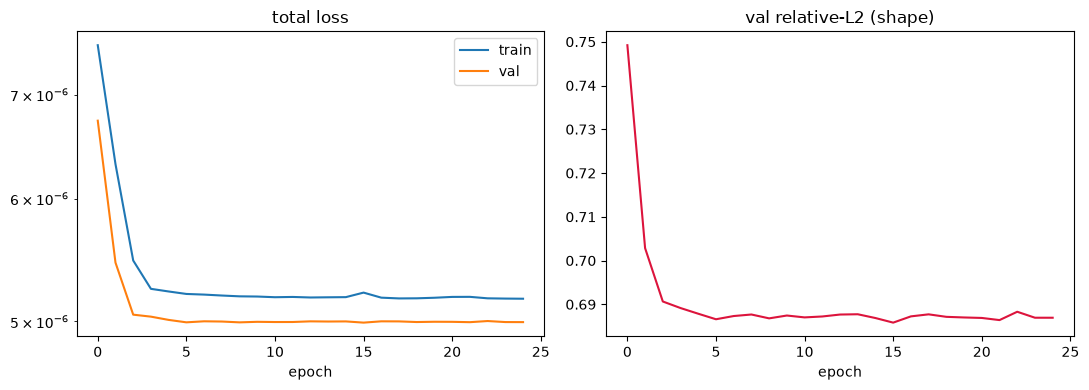

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist["train"], label="train")
ax[0].plot(hist["val"], label="val")
ax[0].set_yscale("log"); ax[0].set_xlabel("epoch"); ax[0].set_title("total loss"); ax[0].legend()
ax[1].plot(hist["val_l2"], color="crimson")
ax[1].set_xlabel("epoch"); ax[1].set_title("val relative-L2 (shape)")
fig.tight_layout()

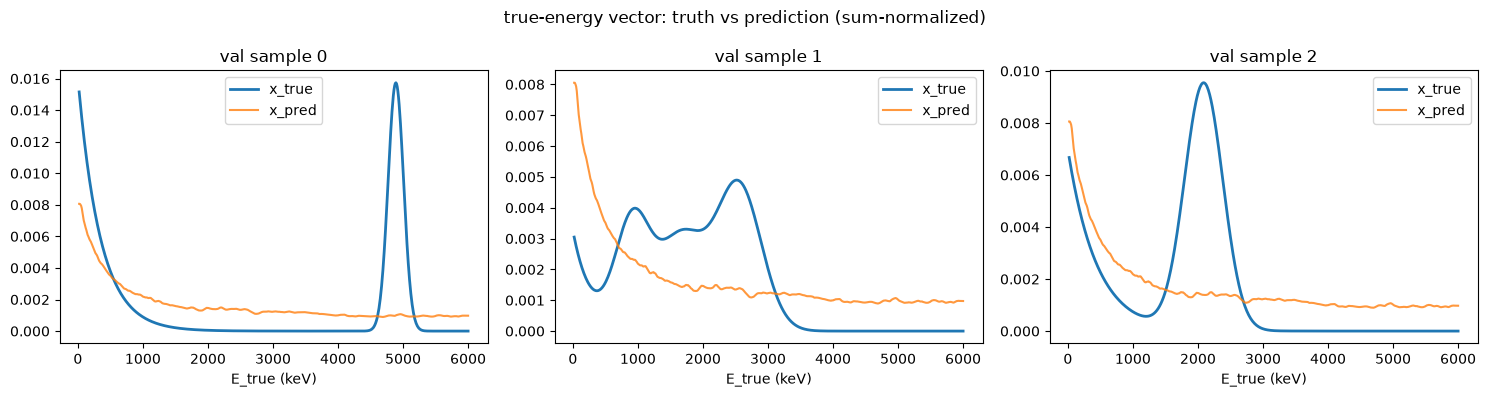

In [8]:
model.eval()
with torch.no_grad():
    xp = model(Y_val[:3].to(DEVICE)).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for k, ax in enumerate(axes):
    ax.plot(rm.e_true_keV, X_val[k].numpy(), label="x_true", lw=2)
    ax.plot(rm.e_true_keV, xp[k], label="x_pred", lw=1.5, alpha=0.8)
    ax.set_xlabel("E_true (keV)"); ax.set_title(f"val sample {k}"); ax.legend()
fig.suptitle("true-energy vector: truth vs prediction (sum-normalized)")
fig.tight_layout()

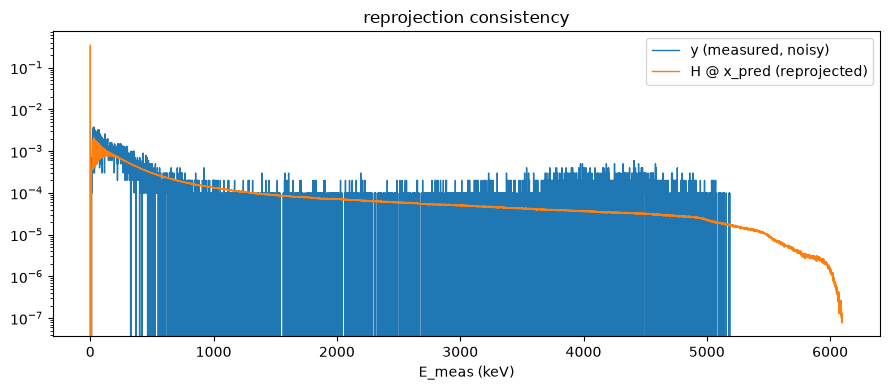

In [9]:
# Physics-space check: reproject the prediction through H and compare to the measurement.
with torch.no_grad():
    xp0 = model(Y_val[:1].to(DEVICE)).cpu().numpy()[0]
y_reproj = H_np @ xp0
y_reproj = y_reproj / y_reproj.sum()

plt.figure(figsize=(9, 4))
plt.plot(rm.e_meas_keV, Y_val[0].numpy(), label="y (measured, noisy)", lw=1)
plt.plot(rm.e_meas_keV, y_reproj, label="H @ x_pred (reprojected)", lw=1)
plt.yscale("log"); plt.xlabel("E_meas (keV)"); plt.legend()
plt.title("reprojection consistency")
plt.tight_layout()

## 8. Save weights

In [10]:
out_dir = REPO / "results"
out_dir.mkdir(exist_ok=True)
ckpt = out_dir / "pinn_transformer_scaffold.pt"
torch.save({"state_dict": model.state_dict(), "cfg": CFG, "history": hist,
            "n_meas": n_meas, "n_true": n_true}, ckpt)
print("saved", ckpt, "(results/ is git-ignored)")

saved d:\projects\DAU_projects\ml-assisted-re-distribution\results\pinn_transformer_scaffold.pt (results/ is git-ignored)


## Next steps

Roughly in order:

1. **Confirm `H`'s identity** with whoever produced `response_matrix.csv` — detector-only
   `H_d`, or already `H_tot`? Everything below branches on this.
2. **Get / build `H_e`** (electron -> HXR, Bethe-Heitler). Form `H_tot = H_d @ H_e` and use
   `H_tot` in `pinn_loss` so `x_pred` actually means the RE distribution `f`.
3. **Fix the units question (Q2)** — decide whether absolute intensity is preserved or only
   shape; drop the sum-normalization if not.
4. **Replace `random_true_distribution`** with a physically justified RE family (bi-Maxwellian
   / parametric high-energy tail — see `project_state/roadmap.md` Stage 6 and the open
   questions), with the supervisor.
5. **Scale up**: more samples, more epochs, LR schedule, dropout/width tuning; the current
   run underfits (val relative-L2 plateaus ~0.69).
6. **Baselines to beat**: classical MLEM (`src.mlem.run_mlem`) on the same synthetic set, and
   the plain transformer on `origin/trial/-transformer`.
7. **Evaluate in physics space** (Level 3 in the roadmap): compare `H_tot @ x_pred` to `y`
   across noise levels and distribution families, not just distribution-space error.
8. Consider **deep-unrolling MLEM** as the architecture instead of / alongside the patch
   transformer (the other Track-2 idea in `project_state`).